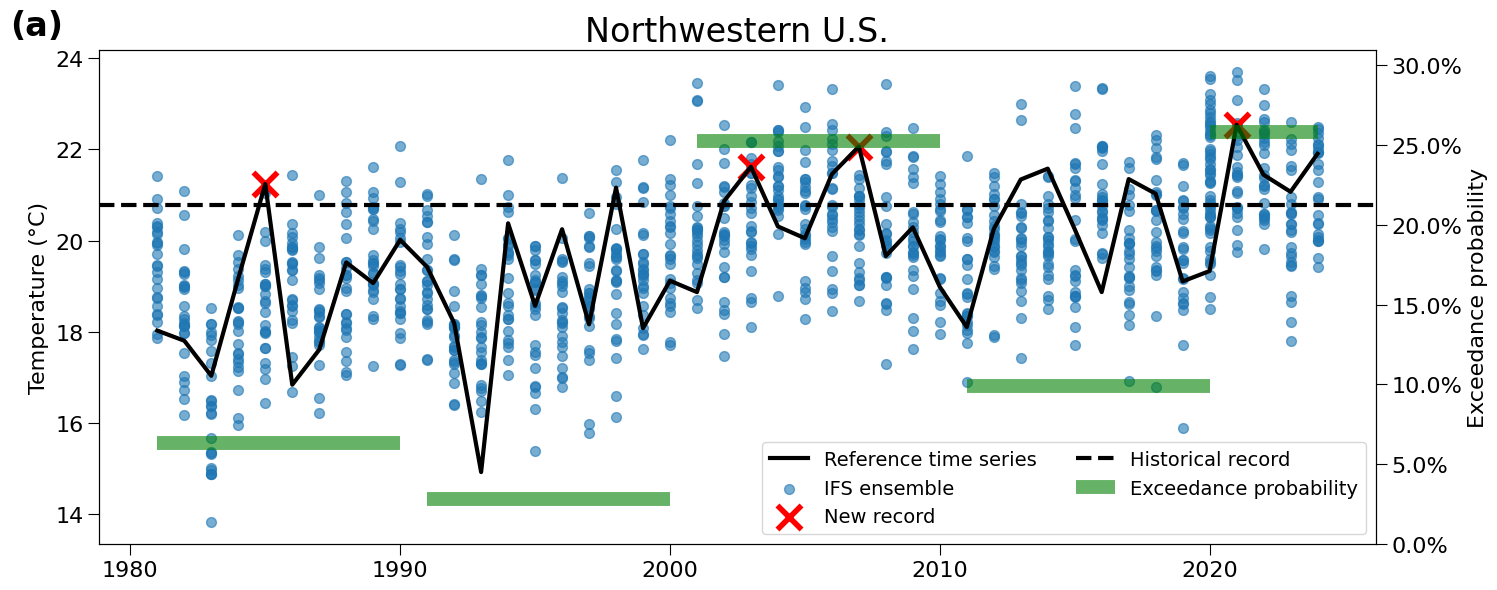

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev
from matplotlib.ticker import PercentFormatter

# === 读取数据 ===
ds_ifs = xr.open_dataset("IFS_t2m_hottest_month.nc")
ds_era5 = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")

ifs_t2m_raw = ds_ifs['t2m_hottest_month'] - 273.15
era5_t2m = ds_era5['t2m_hottest'] - 273.15

ifs_years = ds_ifs['year'].values
era5_years = ds_era5['year'].values

region = 19
region_name = "Northwestern U.S."

# === 时间段 ===
periods = {
    '1981-1990': (1981, 1990),
    '1991-2000': (1991, 2000),
    '2001-2010': (2001, 2010),
    '2011-2020': (2011, 2020),
    '2020-2024': (2020, 2024)
}

# === 分段均值矫正 ===
ifs_t2m_corrected_list = []

for _, (start, end) in periods.items():

    era_mask = (era5_years >= start) & (era5_years <= end)
    ifs_mask = (ifs_years >= start) & (ifs_years <= end)

    era5_mean = era5_t2m.sel(year=era5_years[era_mask]).mean(dim='year')
    ifs_mean = ifs_t2m_raw.sel(year=ifs_years[ifs_mask]).mean(dim=['year','number'])

    bias = era5_mean - ifs_mean

    bias_expanded = bias.expand_dims({
        'year': ds_ifs['year'].sel(year=ifs_years[ifs_mask]),
        'number': ds_ifs['number']
    }).transpose('year','region_id','number')

    corrected = ifs_t2m_raw.sel(year=ifs_years[ifs_mask]) + bias_expanded

    ifs_t2m_corrected_list.append(corrected)

ifs_t2m_corrected = xr.concat(ifs_t2m_corrected_list, dim='year').sortby('year')


# === 绘图函数 ===
def plot_region(ax):

    era5_t2m_region = era5_t2m.sel(region_id=region)

    pre1981_mask = (era5_years >= 1940) & (era5_years < 1981)
    pre1981_max = era5_t2m_region.sel(year=era5_years[pre1981_mask]).max().item()

    post1981_mask = era5_years >= 1981
    years_post1981 = era5_years[post1981_mask]
    t2m_post1981 = era5_t2m_region.sel(year=years_post1981)

    # ERA5
    ax.plot(
        years_post1981,
        t2m_post1981,
        color='k',
        linewidth=3,
        label='Reference time series'
    )

    # IFS ensemble
    ifs_t2m_region = ifs_t2m_corrected.sel(region_id=region)

    for num in range(ifs_t2m_region.number.size):
        label = 'IFS ensemble' if num == 0 else None

        ax.scatter(
            ifs_t2m_region['year'],
            ifs_t2m_region.sel(number=num),
            color='tab:blue',
            alpha=0.6,
            s=50,
            label = label
        )

    # === record breaking ===
    record = pre1981_max
    scatter_years = []
    scatter_temps = []

    for year, temp in zip(years_post1981, t2m_post1981.values):

        if temp > record:

            scatter_years.append(year)
            scatter_temps.append(temp)
            record = temp

    ax.scatter(
        scatter_years,
        scatter_temps,
        color='red',
        marker='x',
        s=300,
        linewidths=4,
        label='New record'
    )

    ax.axhline(
        pre1981_max,
        color='k',
        linestyle='--',
        linewidth=3,
        label='Historical record'
    )

    ax.set_title(region_name, fontsize=24)

    #ax.set_xlabel('Year', fontsize=18)
    ax.set_ylabel('Temperature (°C)', fontsize=16)

    ax.tick_params(labelsize=16, length = 8)

    ax.text(
        -0.07, 1.03, '(a)',
        transform=ax.transAxes,
        fontsize=24,
        fontweight='bold'
    )

    # === GEV probability ===
    ax2 = ax.twinx()

    max_prob = 0

    for i, (_, (start, end)) in enumerate(periods.items()):
        label = 'Exceedance probability' if i == 0 else None

        data = ifs_t2m_corrected.sel(region_id=region)

        data = data.where(
            (data.year >= start) &
            (data.year <= end),
            drop=True
        ).values.flatten()

        data = data[~np.isnan(data)]

        if len(data) < 30:
            continue

        c, loc, scale = gev.fit(data)

        record_val = era5_t2m_region.sel(
            year=era5_years[
                (era5_years >= 1940) &
                (era5_years < start)
            ]
        ).max().item()

        prob = 1 - gev.cdf(record_val, c, loc=loc, scale=scale)

        max_prob = max(max_prob, prob)

        ax2.hlines(
            prob,
            start,
            end,
            linewidth=10,
            color='green',
            alpha=0.6,
            label=label
        )

    ax2.set_ylim(0, max_prob * 1.2 if max_prob > 0 else 0.1)

    ax2.set_ylabel(
        'Exceedance probability',
        fontsize=16
    )

    ax2.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    ax2.tick_params(labelsize=16, length = 8)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc='lower right',
        fontsize=14,
        frameon=True,
        ncol=2
    )


# === 创建宽图 ===
fig, ax = plt.subplots(figsize=(15,6))

plot_region(ax)

plt.tight_layout()

plt.savefig(
    "time_series_region_a.pdf",
    dpi=400,
    # bbox_inches='tight'
)

plt.show()

Processing 1981-1990...
Processing 1991-2000...
Processing 2001-2010...
Processing 2011-2020...
Processing 2020-2024...
Saved to record_breaking_probability_raw.nc


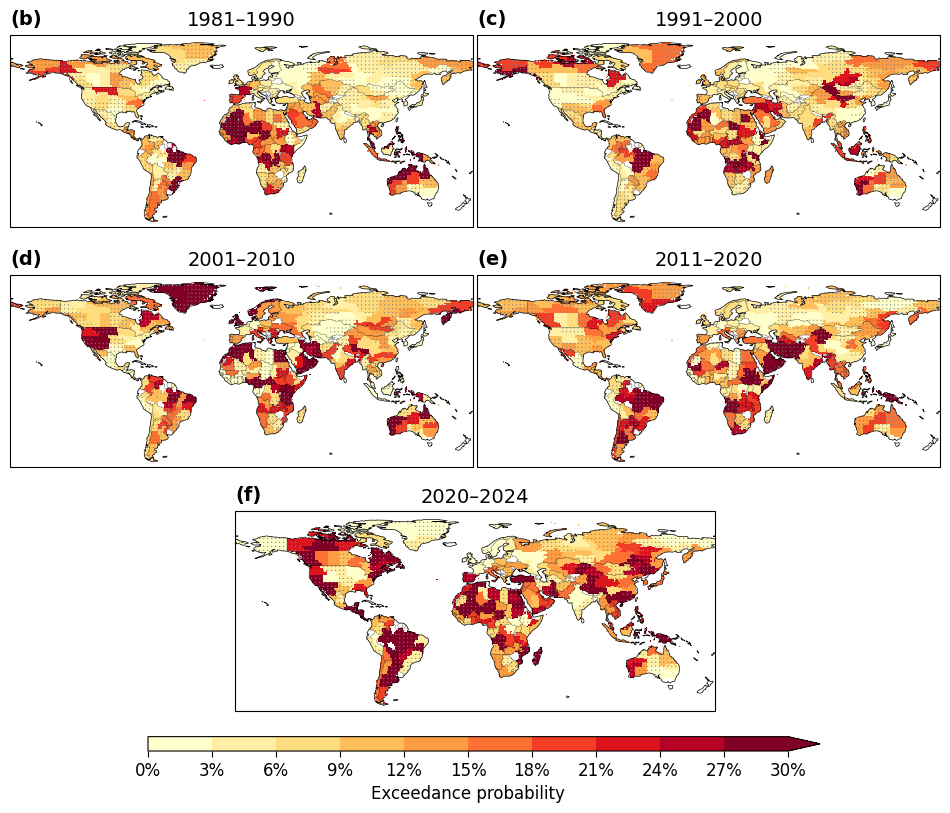

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec

# === 加载数据 ===
ecmwf_ds = xr.open_dataset("IFS_t2m_hottest_month.nc")
rl_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/grid_comparison_fidelity_trend_corrected.nc"
)

region_ids = mask_ds['region_id'].values
lat = mask_ds['latitude'].values
lon = mask_ds['longitude'].values

fidelity = fidelity_ds["fidelity_score"]

# fidelity mask
fidelity_mask = fidelity == 3
hatch_mask = (~fidelity_mask.values) & (~np.isnan(region_ids))

t2m_ifs_all = ecmwf_ds['t2m_hottest_month']
t2m_berkeley_all = rl_ds['t2m_hottest']

n_regions = 237

time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020),
    (2020, 2024)
]

n_periods = len(time_periods)


# =========================================================
# 工具函数
# =========================================================
def get_max_before_year(ds, start, end):
    sub = ds.sel(year=(ds.year >= start) & (ds.year <= end))
    return sub['t2m_hottest'].max(dim='year')


# =========================================================
# 初始化概率矩阵
# =========================================================
prob_map = np.full((n_regions, n_periods), np.nan)


# =========================================================
# 分时间段计算概率
# =========================================================
for i, (start, end) in enumerate(time_periods):

    print(f"Processing {start}-{end}...")

    period_mask_ifs = (
        (ecmwf_ds.year >= start)
        & (ecmwf_ds.year <= end)
    )

    period_mask_berkeley = (
        (rl_ds.year >= start)
        & (rl_ds.year <= end)
    )

    t2m_ifs_period = t2m_ifs_all.sel(year=period_mask_ifs)
    t2m_berkeley_period = t2m_berkeley_all.sel(year=period_mask_berkeley)

    # bias correction
    ifs_mean = t2m_ifs_period.mean(dim='year')
    berkeley_mean = t2m_berkeley_period.mean(dim='year')

    t2m_corrected = (
        t2m_ifs_period
        - ifs_mean
        + berkeley_mean
    )

    # historical record before current period
    max_t2m = get_max_before_year(rl_ds, 1940, start - 1)

    # reshape
    values = (
        t2m_corrected.values
        .transpose(0, 2, 1)
        .reshape(-1, n_regions)
    )

    for r in range(n_regions):

        series = values[:, r]
        series = series[~np.isnan(series)]

        if len(series) < 30:
            continue

        try:
            c, loc, scale = gev.fit(series)

            x = max_t2m.sel(region_id=r).item()

            F = gev.cdf(x, c, loc=loc, scale=scale)

            prob_map[r, i] = 1 - F

        except Exception:
            continue


# =========================================================
# 保存为 NetCDF 文件
# =========================================================
period_labels = [
    f"{start}-{end}"
    for start, end in time_periods
]

prob_ds_out = xr.Dataset(
    {
        "record_breaking_probability": (
            ("region_id", "period"),
            prob_map
        )
    },
    coords={
        "region_id": np.arange(n_regions),
        "period": period_labels
    }
)

prob_ds_out.to_netcdf(
    "record_breaking_probability_raw.nc"
)

print("Saved to record_breaking_probability_raw.nc")


# =========================================================
# 色标设置
# =========================================================
bounds = np.arange(0, 0.301, 0.03)

cmap = plt.get_cmap(
    "YlOrRd",
    len(bounds) - 1
)

norm = BoundaryNorm(
    boundaries=bounds,
    ncolors=cmap.N
)


# =========================================================
# 单幅地图函数
# =========================================================
def plot_prob_map(
    region_data,
    title,
    ax,
    dot_size=0.8,
    dot_color='grey'
):

    # === 填充区域数据 ===
    map_data = np.full_like(
        region_ids,
        np.nan,
        dtype=np.float64
    )

    for r in range(n_regions):
        map_data[region_ids == r] = region_data[r]

    masked_data = np.ma.masked_invalid(map_data)

    # === 主图 ===
    im = ax.pcolormesh(
        lon,
        lat,
        masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # =====================================================
    # fidelity != 3 区域加灰点
    # =====================================================
    low_fid_mask = hatch_mask

    lons_dot, lats_dot = np.meshgrid(lon, lat)

    rows, cols = np.where(low_fid_mask)

    row_step = 3
    col_step = 3

    mask_sparse = (
        (rows % row_step == 0)
        & (cols % col_step == 0)
    )

    rows_sparse = rows[mask_sparse]
    cols_sparse = cols[mask_sparse]

    lons_dot = lons_dot[rows_sparse, cols_sparse]
    lats_dot = lats_dot[rows_sparse, cols_sparse]

    ax.scatter(
        lons_dot,
        lats_dot,
        s=dot_size,
        c=dot_color,
        marker='o',
        edgecolors='none',
        transform=ccrs.PlateCarree(),
        alpha=1
    )

    # === 地图设置 ===
    ax.set_extent(
        [-180, 180, -60, 90],
        crs=ccrs.PlateCarree()
    )

    ax.coastlines(linewidth=0.5)

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.2
    )

    ax.set_title(
        title,
        fontsize=14
    )

    return im


# =========================================================
# 主绘图函数
# =========================================================
def plot_gev_probability_grid(prob_map, fig_title):

    # =====================================================
    # Figure
    # =====================================================
    fig = plt.figure(figsize=(12, 8))

    # 3行6列布局
    gs = GridSpec(
        3,
        6,
        figure=fig,
        height_ratios=[1, 1, 1]
    )

    # =====================================================
    # 子图布局
    # =====================================================

    # 第一行
    ax_a = fig.add_subplot(
        gs[0, 0:3],
        projection=ccrs.PlateCarree()
    )

    ax_b = fig.add_subplot(
        gs[0, 3:6],
        projection=ccrs.PlateCarree()
    )

    # 第二行
    ax_c = fig.add_subplot(
        gs[1, 0:3],
        projection=ccrs.PlateCarree()
    )

    ax_d = fig.add_subplot(
        gs[1, 3:6],
        projection=ccrs.PlateCarree()
    )

    # 第三行（居中）
    ax_e = fig.add_subplot(
        gs[2, 1:5],
        projection=ccrs.PlateCarree()
    )

    axs = [ax_a, ax_b, ax_c, ax_d, ax_e]

    labels = ['(b)', '(c)', '(d)', '(e)', '(f)']

    # =====================================================
    # 绘制子图
    # =====================================================
    for i, ax in enumerate(axs):

        title = (
            f"{time_periods[i][0]}"
            f"–"
            f"{time_periods[i][1]}"
        )

        data = prob_map[:, i]

        im = plot_prob_map(
            data,
            title,
            ax
        )

        ax.text(
            0.00,
            1.03,
            labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            ha='left',
            va='bottom'
        )

    # =====================================================
    # 子图间距
    # =====================================================
    fig.subplots_adjust(
        wspace=0.03,
        hspace=0.20,
        top=0.95,
        bottom=0.1
    )

    # =====================================================
    # Colorbar
    # =====================================================
    cbar_ax = fig.add_axes(
        [0.24, 0.05, 0.56, 0.018]
    )

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(
            norm=norm,
            cmap=cmap
        ),
        cax=cbar_ax,
        orientation='horizontal',
        ticks=bounds,
        extend='max'
    )

    formatter = FuncFormatter(
        lambda x, _: f"{x * 100:.0f}%"
    )

    cbar.ax.set_xticklabels(
        [formatter(t) for t in bounds]
    )

    cbar.ax.tick_params(
        labelsize=12,
        length=4
    )

    cbar.set_label(
        "Exceedance probability",
        fontsize=12
    )

    # =====================================================
    # 保存
    # =====================================================
    plt.savefig(
        "Fig2_record_breaking_probability_all_periods.pdf",
        dpi=800,
        bbox_inches='tight'
    )

    plt.show()


# =========================================================
# 执行
# =========================================================
plot_gev_probability_grid(
    prob_map,
    "Probability of record-breaking events by period"
)

In [11]:
import fitz  # PyMuPDF

# =========================================================
# 输入文件
# =========================================================
file1 = "time_series_region_a.pdf"
file2 = "Fig2_record_breaking_probability_all_periods.pdf"

# 输出文件
output_file = "Combined_Figure.pdf"

# =========================================================
# 打开 PDF
# =========================================================
doc1 = fitz.open(file1)
doc2 = fitz.open(file2)

# =========================================================
# 创建输出 PDF
# =========================================================
output = fitz.open()

# =========================================================
# 默认假设两个 PDF 都只有 1 页
# =========================================================
page1 = doc1[0]
page2 = doc2[0]

# 获取页面尺寸
rect1 = page1.rect
rect2 = page2.rect

width1 = rect1.width
height1 = rect1.height

width2 = rect2.width
height2 = rect2.height

# =========================================================
# 新页面大小
# 宽度取最大值
# 高度为两页高度之和
# =========================================================
new_width = max(width1, width2)
new_height = height1 + height2

new_page = output.new_page(
    width=new_width,
    height=new_height*1.4
)

# =========================================================
# 插入第一页（上）
# =========================================================
new_page.show_pdf_page(
    fitz.Rect(
        0,
        0,
        width1,
        height1
    ),
    doc1,
    0
)

# =========================================================
# 插入第二页（下）
# =========================================================
new_page.show_pdf_page(
    fitz.Rect(
        0,
        height1,
        width1,
        height1 + height2*1.7
    ),
    doc2,
    0
)

# =========================================================
# 保存
# =========================================================
output.save(output_file)

# 关闭文件
output.close()
doc1.close()
doc2.close()

print(f"Saved: {output_file}")

Saved: Combined_Figure.pdf


In [1]:
import xarray as xr

ds = xr.open_dataset("record_breaking_probability_raw.nc")

print(ds)

<xarray.Dataset> Size: 12kB
Dimensions:                      (region_id: 237, period: 5)
Coordinates:
  * region_id                    (region_id) int64 2kB 0 1 2 3 ... 234 235 236
  * period                       (period) <U9 180B '1981-1990' ... '2020-2024'
Data variables:
    record_breaking_probability  (region_id, period) float64 9kB ...
